In [7]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [8]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
LATRANGE  = CONFIGS['domain']['latrange']
LONRANGE  = CONFIGS['domain']['lonrange']
SPLIT     = 'valid'

In [9]:
# Load z-score stats and normalized split
with open(os.path.join(SPLITSDIR, 'stats.json'), 'r', encoding='utf-8') as f:
    stats = json.load(f)

with xr.open_dataset(os.path.join(SPLITSDIR, f'norm_{SPLIT}.h5'), engine='h5netcdf') as ds:
    lf_z  = ds['lf'].load()   # (lat, lon) — static land fraction, z-scored
    shf_z = ds['shf'].load()  # (lat, lon, time) — sensible heat flux, z-scored

# Broadcast static LF to match SHF time dimension
lf_z_full = lf_z.expand_dims(time=shf_z.time).broadcast_like(shf_z)

# Derived quantities for SR-HI: max(lf_z, shf_z) · d
max_z      = xr.apply_ufunc(np.maximum, lf_z_full, shf_z)
lf_wins    = (lf_z_full > shf_z).mean('time')  # fraction where LF dominates

# Time means
shf_z_mean = shf_z.mean('time')
max_z_mean = max_z.mean('time')

# Native units for reference panels
lf_mean_val  = stats.get('lf_mean', 0.0);  lf_std_val  = stats.get('lf_std', 1.0)
shf_mean_val = stats.get('shf_mean', 0.0); shf_std_val = stats.get('shf_std', 1.0)
lf_native  = lf_z  * lf_std_val  + lf_mean_val
shf_native = shf_z_mean * shf_std_val + shf_mean_val

lf_wins_pct = 100 * float((lf_z_full.values > shf_z.values).mean())
print(f'LF wins at {lf_wins_pct:.1f}% of all (time, lat, lon) samples')

LF wins at 30.2% of all (time, lat, lon) samples


In [10]:
# Compute derived quantities at each (time, lat, lon)
max_term = xr.apply_ufunc(np.maximum, lf_z_full, shf_z)   # max(lf_z, shf_z)
abs_term = abs(lf_z_full - shf_z)                          # abs(lf_z - shf_z)
lf_wins  = (lf_z_full > shf_z).astype(float)              # 1 where lf dominates

# Time-average each quantity
lf_z_mean   = lf_z if 'time' not in lf_z.dims else lf_z.mean('time')
shf_z_mean  = shf_z.mean('time')
max_mean     = max_term.mean('time')
abs_mean     = abs_term.mean('time')
lf_wins_frac = lf_wins.mean('time')  # fraction of time steps where lf_z > shf_z

# Native-unit time means for reference
lf_mean_val  = stats.get('lf_mean',  0.0)
lf_std_val   = stats.get('lf_std',   1.0)
shf_mean_val = stats.get('shf_mean', 0.0)
shf_std_val  = stats.get('shf_std',  1.0)

lf_native  = lf_z_mean  * lf_std_val  + lf_mean_val
shf_native = shf_z_mean * shf_std_val + shf_mean_val

print('Time-mean lf_z:', float(lf_z_mean.mean()), '(should be ~0 if static with zero mean after z-score)')
print('Time-mean shf_z:', float(shf_z_mean.mean()))

Time-mean lf_z: -7.031700022253062e-08 (should be ~0 if static with zero mean after z-score)
Time-mean shf_z: 0.013705512508749962


ValueError: Input shapes x (31,) and y (21,) must match array centers (21, 31, 2208) or array borders (22, 32, 2209).

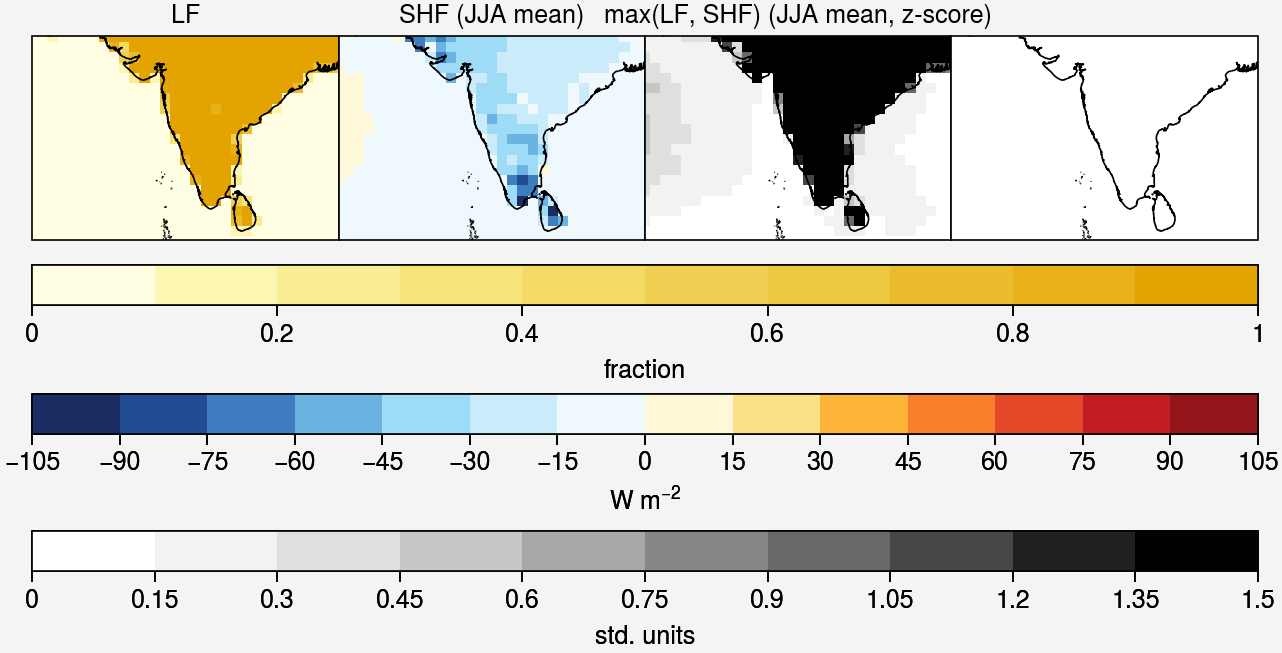

In [11]:
# ── 4-panel figure: LF (native) | SHF mean (native) | max(LF,SHF) z-score | LF-wins fraction ──
fig, axs = pplt.subplots(nrows=1, ncols=4, proj='cyl', figwidth=6.5, share=False, wspace=0)
axs.format(coast=True, borders=False, latlim=LATRANGE, lonlim=LONRANGE,
           latlines=5, lonlines=5, grid=False)

m0 = axs[0].pcolormesh(lf_native.lon, lf_native.lat, lf_native,
                        cmap='yellows1', vmin=0, vmax=1, levels=11)
axs[0].format(title='LF')
fig.colorbar(m0, loc='b', label='fraction', ticks=0.2)

shf_lim = max(abs(float(shf_native.min())), abs(float(shf_native.max())))
m1 = axs[1].pcolormesh(shf_native.lon, shf_native.lat, shf_native,
                        cmap='ColdHot', vmin=-shf_lim, vmax=shf_lim, levels=21)
axs[1].format(title='SHF (JJA mean)')
fig.colorbar(m1, loc='b', label='W m$^{-2}$')

vmax_max = float(max_z_mean.quantile(0.99))
m2 = axs[2].pcolormesh(max_z_mean.lon, max_z_mean.lat, max_z_mean,
                        cmap='Grays', vmin=0, vmax=vmax_max, levels=11)
axs[2].format(title='max(LF, SHF) (JJA mean, z-score)')
fig.colorbar(m2, loc='b', label='std. units')

m3 = axs[3].pcolormesh(lf_wins.lon, lf_wins.lat, lf_wins,
                        cmap='DryWet', vmin=0, vmax=1, levels=11)
axs[3].format(title='Fraction: LF wins')
fig.colorbar(m3, loc='b', label='fraction', ticks=0.2)

pplt.show()
# fig.save('../figs/fig_surface_terms.jpg')

In [12]:
# Crossover diagnostics: when does LF_z exceed SHF_z and by how much?
lf_arr  = lf_z_full.values.ravel()
shf_arr = shf_z.values.ravel()
fin     = np.isfinite(lf_arr) & np.isfinite(shf_arr)

print(f'LF wins at {lf_wins_pct:.1f}% of all (time, lat, lon) samples')
print(f'lf_z  : mean={lf_arr[fin].mean():.3f}  std={lf_arr[fin].std():.3f}  '\
      f'range=[{lf_arr[fin].min():.2f}, {lf_arr[fin].max():.2f}]')
print(f'shf_z : mean={shf_arr[fin].mean():.3f}  std={shf_arr[fin].std():.3f}  '\
      f'range=[{shf_arr[fin].min():.2f}, {shf_arr[fin].max():.2f}]')

# Native LF value at the crossover point (mean SHF_z level)
shf_z_mean_val = float(shf_arr[fin].mean())
lf_crossover   = shf_z_mean_val * lf_std_val + lf_mean_val
print(f'\nCrossover: shf_z global mean = {shf_z_mean_val:.3f} → native LF ≈ {lf_crossover:.3f}')

LF wins at 30.2% of all (time, lat, lon) samples
lf_z  : mean=-0.000  std=1.000  range=[-0.66, 1.60]
shf_z : mean=0.014  std=0.958  range=[-11.67, 3.24]

Crossover: shf_z global mean = 0.014 → native LF ≈ 0.299
